In [1]:
%load_ext autoreload
%autoreload 2

from pklibs import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import pkindicators  # Assuming your C module is compiled and installed as pkindicators

# Generate sample data (you should replace this with real OHLCV data)
# dates = pd.date_range('2022-01-01', periods=1000, freq='D')
# prices = np.random.randn(1000).cumsum() + 100  # Simulated price data
# data = pd.DataFrame(prices, columns=['close'], index=dates)


In [56]:
exchange,base,quote,timeframe = 'binance','BTC', 'USDT', '8h'
data = load_candles(exchange,base,quote,timeframe).apply(np.log).iloc[-3000:]
data

,open,high,low,close,volume
timestamp,,,,,
2021-11-19 16:00:00,10.966265,10.973700,10.960081,10.969099,9.396383
2021-11-20 00:00:00,10.969182,10.984953,10.967036,10.974730,9.217812
2021-11-20 08:00:00,10.974730,10.982492,10.959252,10.961076,9.246869
2021-11-20 16:00:00,10.961076,10.999513,10.956980,10.997213,9.500361
2021-11-21 00:00:00,10.997213,10.998272,10.976782,10.985000,9.117887
...,...,...,...,...,...
2024-08-14 00:00:00,11.011838,11.023582,11.009158,11.017219,8.340903
2024-08-14 08:00:00,11.017219,11.031659,10.982297,10.992650,9.739477
2024-08-14 16:00:00,10.992650,10.993103,10.975639,10.979912,8.889615


In [38]:
# # Calculate ZigZag indicators
# epsilon = 0.5  # Example epsilon, adjust as needed
# zigzag, markers, _ = pkindicators.calculate_zigzag(data['close'].values, epsilon)
# data['ZigZag'] = zigzag
# data['Markers'] = markers


In [ ]:
fib_levels = np.array([-1.0, -0.786, -0.618, -0.5, -0.382, -0.236, 0.0, 0.236, 0.382, 0.5, 0.618, 0.786, 1.0, 1.236, 1.5, 1.618, 1.786, 2.0, 2.236, 2.382, 2.5, 2.628, 2.786, 3, 3.382, 3.618, 4, 5])

fib_columns = [f'fib({fib})' for fib in fib_levels]
# fib_columns 

def calculate_fib_levels(highs, lows, directions, fib_levels=fib_levels):
    # Ensure highs, lows, and directions are numpy arrays
    highs = np.asarray(highs)
    lows = np.asarray(lows)
    directions = np.asarray(directions)

    # Flip highs and lows based on direction (-1 means flip)
    adjusted_highs = np.where(directions == 1, highs, lows)
    adjusted_lows = np.where(directions == 1, lows, highs)

    # Calculate the difference between adjusted high and low
    diff = adjusted_highs - adjusted_lows

    # Calculate the Fibonacci levels by applying the levels to the differences
    fib_matrix = np.outer(diff, fib_levels)
    
    # Calculate the actual levels by adding them to the low (base) level
    fib_levels_array = adjusted_lows[:, np.newaxis] + fib_matrix

    return fib_levels_array


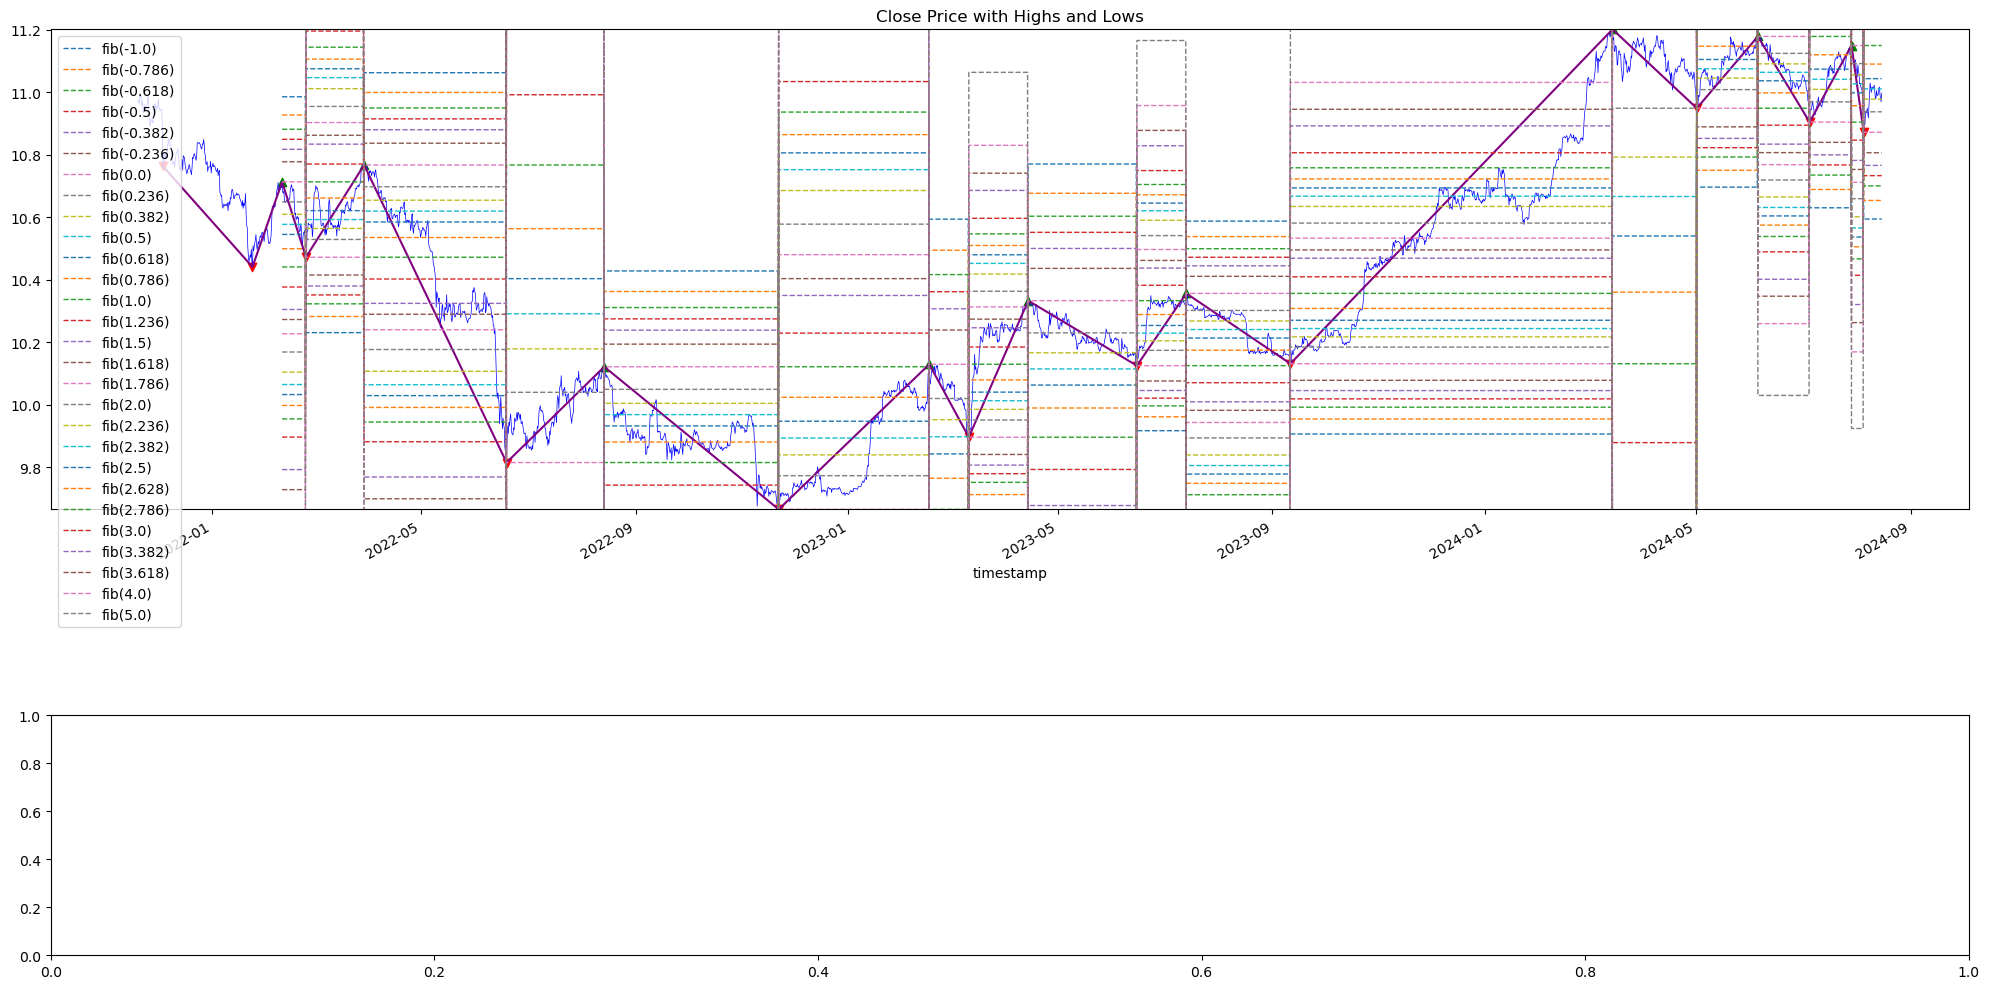

In [87]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_highs_lows_with_fibs(data, epsilon, window=None):
    """
    Plot close prices with highs and lows markers, and Fibonacci levels.

    Parameters:
    - data: DataFrame containing OHLCV data with a 'close' column.
    - epsilon: Epsilon value used for the ZigZag calculation.
    - window: Optional tuple (start, end) to define the plotting window.
    """

    # Call the calculate_zigzag function from the C module
    high_low_markers, turning_points = pkindicators.calculate_zigzag(data['close'].values, epsilon=epsilon)

    # Store the results back into the DataFrame for easier plotting
    data['HighLowMarkers'] = high_low_markers
    data['TurningPoints'] = turning_points

    # Get the indices of highs and lows
    highs_idx = data.index[data['HighLowMarkers'] == 1]
    lows_idx = data.index[data['HighLowMarkers'] == -1]

    running_highs = (np.where(high_low_markers == 1, 1, np.nan) * data['close']).ffill()
    running_lows = (np.where(high_low_markers == -1, 1, np.nan) * data['close']).ffill()

    running_highs_idx = pd.Series(np.where(high_low_markers == 1, 1, np.nan) * np.arange(len(data))).set_axis(data.index).ffill()
    running_lows_idx = pd.Series(np.where(high_low_markers == -1, 1, np.nan) * np.arange(len(data))).set_axis(data.index).ffill()

    # Combine the indices and sort them
    turning_points_idx = sorted(highs_idx.union(lows_idx))

    # Assuming calculate_fib_levels is defined elsewhere in your code
    fibs = calculate_fib_levels(running_lows, running_highs, ((running_highs_idx > running_lows_idx) * 2 - 1))
    df_fibs = pd.DataFrame(fibs, columns=fib_columns, index=data.index)

    # If a window is specified, slice the data
    if window is not None:
        start, end = window
        data_to_plot = data.iloc[start:end]
        df_fibs_to_plot = df_fibs.iloc[start:end]
    else:
        data_to_plot = data
        df_fibs_to_plot = df_fibs

    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10),height_ratios=[2,1])

    # Plot on the first axis
    ax1.plot(data_to_plot.index, data_to_plot['close'], label='Close Price', color='blue', lw=0.5)

    # Plot the highs and lows markers
    highs = data_to_plot[data_to_plot['HighLowMarkers'] == 1]
    lows = data_to_plot[data_to_plot['HighLowMarkers'] == -1]
    ax1.scatter(highs.index, highs['close'], color='green', marker='^', label='Highs')
    ax1.scatter(lows.index, lows['close'], color='red', marker='v', label='Lows')
    
        # Plot the highs and lows on the combined turning points index
    ax1.plot(data.loc[turning_points_idx].index, data.loc[turning_points_idx, 'close'], color='purple', label='ZigZag Line', lw=1.5)

    # ax1.plot(running_highs.index, running_highs, color='black', linestyle='-', label='Running Highs', lw=0.5)
    # ax1.plot(running_lows.index, running_lows, color='black', linestyle='-', label='Running Lows', lw=0.5)


    # Draw lines connecting consecutive highs and lows
    # for i in range(1, len(highs)):
    #     ax1.plot([highs.index[i-1], highs.index[i]], [highs['close'].iloc[i-1], highs['close'].iloc[i]], 'green', lw=1)
    # for i in range(1, len(lows)):
    #     ax1.plot([lows.index[i-1], lows.index[i]], [lows['close'].iloc[i-1], lows['close'].iloc[i]], 'red', lw=1)


    # Plot the Fibonacci levels
    df_fibs_to_plot.plot(ax=ax1, linestyle='--', lw=1)

    # Set the y-axis limits based on the close price
    ax1.set_ylim(data_to_plot.close.min(), data_to_plot.close.max())

    # Adding legend and title to the first axis
    # ax1.legend(loc='best')
    ax1.set_title('Close Price with Highs and Lows')

    # The second axis is available for additional plots or leave it empty
    # ax2.plot(...)  # Add your plot here if needed

    # Display the plot
    plt.tight_layout()
    # plt.legend(False)
    plt.show()

# Example usage:
# plot_highs_lows_with_fibs(data, epsilon=0.2, window=(100, 200))



# Adding legend and title
# plt.grid(axis='y')  # Horizontal grid only

plot_highs_lows_with_fibs(data, epsilon=0.2)